In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,  # Fixed the spelling typo here
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)


In [4]:
credit_card = pd.read_csv("creditcard.csv")
print("Data Loaded Successfully")

Data Loaded Successfully


In [5]:
print(credit_card.shape)
print(credit_card["Class"].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


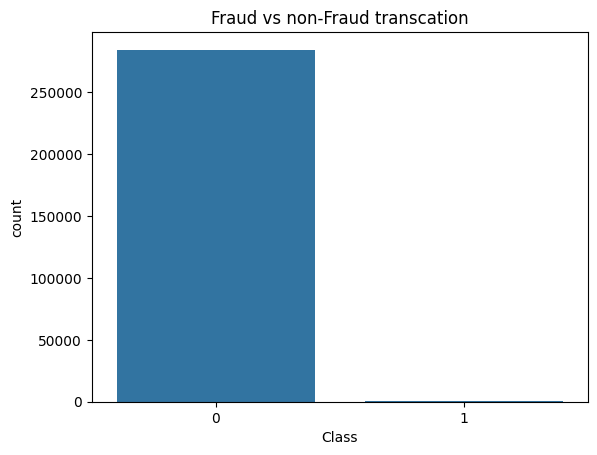

In [6]:
sns.countplot(x="Class", data = credit_card)
plt.title("Fraud vs non-Fraud transcation")
plt.show()

In [7]:
X = credit_card.drop("Class",axis = 1)

Y = credit_card["Class"]

X_train,X_test,Y_train,Y_test = train_test_split(
        X,Y,test_size=0.30)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [8]:
model1 = LogisticRegression()
model2 = KNeighborsClassifier()
model3 = DecisionTreeClassifier()

model1.fit(X_train,Y_train)
model2.fit(X_train,Y_train)
model3.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
Y_pred1 = model1.predict(X_test)
Y_pred2 = model2.predict(X_test)
Y_pred3 = model3.predict(X_test)

In [13]:
acc1 = accuracy_score(Y_test,Y_pred1)
prec1 = precision_score(Y_test,Y_pred1)
rec1 = recall_score(Y_test,Y_pred1)
f1_1 = f1_score(Y_test,Y_pred1)


acc2 = accuracy_score(Y_test,Y_pred2)
prec2 = precision_score(Y_test,Y_pred2)
rec2 = recall_score(Y_test,Y_pred2)
f1_2 = f1_score(Y_test,Y_pred2)


acc3 = accuracy_score(Y_test,Y_pred3)
prec3 = precision_score(Y_test,Y_pred3)
rec3 = recall_score(Y_test,Y_pred3)
f1_3 = f1_score(Y_test,Y_pred3)

In [16]:
results = pd.DataFrame(
    {
        "Model":["Logistic Regression","KNN","Decision Tree"],
        "Accuracy":[acc1,acc2,acc3],
        "Percision": [prec1,prec2,prec3],
        "Recall":[rec1,rec2,rec3],
        "F1_score":[f1_1,f1_2,f1_3]
    }
)

In [24]:
print("Model Comparision:")

print(results.sort_values(by="F1_score", ascending=False))


Model Comparision:
                 Model  Accuracy  Percision    Recall  F1_score
1                  KNN  0.999567   0.953125  0.797386  0.868327
2        Decision Tree  0.999146   0.746914  0.790850  0.768254
0  Logistic Regression  0.999111   0.873786  0.588235  0.703125


In [23]:
print(results.columns.tolist())


['Model', 'Accuracy', 'Percision', 'Recall', 'F1_score']
